# Linear Regression

**Linear Regression** is a supervised machine learning algorithm used to **predict continuous values** by understanding the **linear relationship between independent variables and a dependent variable**.

Linear Regression is a **Parametric Model**, meaning it assumes a specific functional form with parameters.

---

## Types of Linear Regression

1. **Simple Linear Regression**
2. **Multiple Linear Regression**

---

## 1. Simple Linear Regression

Simple Linear Regression models the relationship between **one independent variable** and **one dependent variable**.

### Formula

$$
y = \alpha + \beta x
$$

### Parameters

- **α (Alpha)** → Intercept  
- **β (Beta)** → Coefficient of Regression (slope)

### Variables

- **y** → Dependent Variable  
  - Also called: *Response* / *Outcome*

- **x** → Independent Variable  
  - Also called: *Predictor* / *Explanatory Variable*

---

![SLR](image-folder/SLR.PNG)

In [1]:
import pandas as pd
import numpy as np

data = pd.read_csv('dataset-folder/student_scores.csv')

data.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [2]:
data.shape

(25, 2)

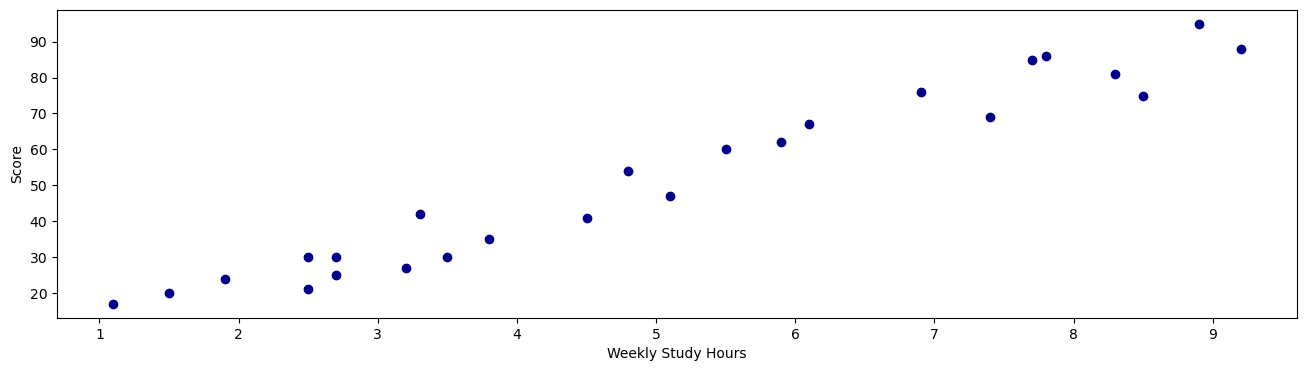

In [3]:
import matplotlib.pyplot as plt

# plt.style.use("dark_background")
plt.figure(figsize = (16,4))
plt.scatter(data["Hours"],data["Scores"], color = 'darkblue')
plt.xlabel("Weekly Study Hours")
plt.ylabel("Score")
plt.show()

In [4]:
from sklearn.linear_model import LinearRegression
y = data["Scores"]
x = data[["Hours"]]

linR = LinearRegression()
model_lr = linR.fit(x,y) #train

In [5]:
model_lr.predict([[6.5]])

C:\Users\arunk\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([66.02639545])

In [6]:
pred = model_lr.predict(data[["Hours"]])

In [7]:
pred

array([26.92318188, 52.3402707 , 33.76624426, 85.57800223, 36.69898527,
       17.14737849, 92.4210646 , 56.25059205, 83.62284155, 28.87834256,
       77.75735951, 60.16091341, 46.47478866, 34.74382459, 13.23705714,
       89.48832358, 26.92318188, 21.05769985, 62.11607409, 74.8246185 ,
       28.87834256, 49.40752968, 39.63172629, 69.9367168 , 78.73493985])

In [8]:
data[["Hours"]]

,Hours
0,2.5
1,5.1
2,3.2
3,8.5
4,3.5
5,1.5
6,9.2
7,5.5
8,8.3
9,2.7


In [9]:
data['predicted_values'] = pred

In [10]:
data.sort_values(by = "Hours")

,Hours,Scores,predicted_values
14,1.1,17,13.237057
5,1.5,20,17.147378
17,1.9,24,21.057700
0,2.5,21,26.923182
16,2.5,30,26.923182
20,2.7,30,28.878343
9,2.7,25,28.878343
2,3.2,27,33.766244
13,3.3,42,34.743825
4,3.5,30,36.698985


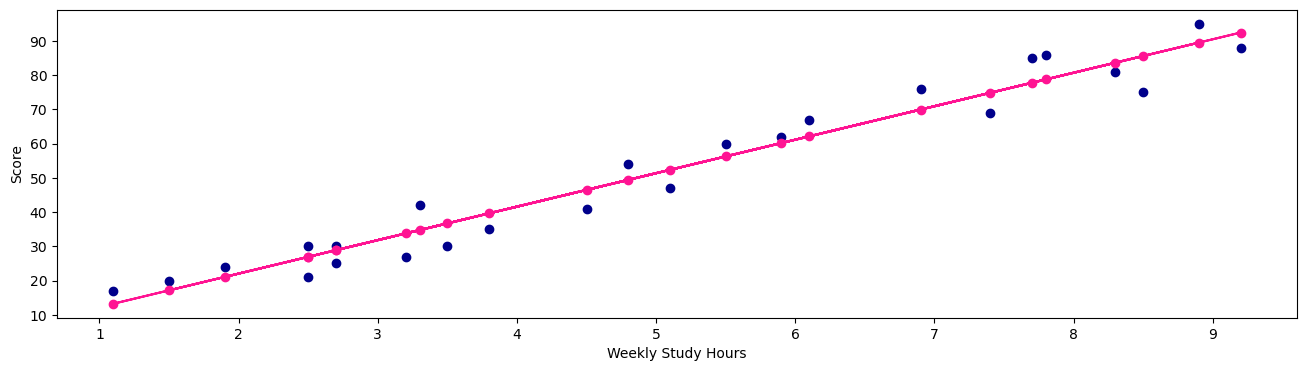

In [11]:
# plt.style.use("dark_background")
plt.figure(figsize=(16,4))

plt.scatter(data["Hours"], data["Scores"], color="darkblue")
plt.plot(data["Hours"], data["predicted_values"], color="deeppink", marker='o')

plt.xlabel("Weekly Study Hours")
plt.ylabel("Score")

plt.show()

![SLR](image-folder/SLR-actual-vs-predicted.PNG)

In [12]:
data['Residual'] = abs(data['Scores'] - data['predicted_values']) # Loss Function

In [15]:
data.sort_values(by = "Hours").head()

,Hours,Scores,predicted_values,Residual
14,1.1,17,13.237057,3.762943
5,1.5,20,17.147378,2.852622
17,1.9,24,21.057700,2.942300
0,2.5,21,26.923182,5.923182
16,2.5,30,26.923182,3.076818


In [16]:
model_lr.coef_ # 𝛽

array([9.77580339])

In [18]:
model_lr.intercept_ # 𝛼

2.483673405373196

In [19]:
# y = 𝛼 + 𝛽x + e

# data['Scores'] = 2.483673405373196 + 9.77580339 * data['Hours'] + 3.762943

2.483673405373196 + (9.77580339 *1.1) + 3.762943

17.000000134373195

## 2. Multiple Linear Regression

Multiple Linear Regression models the relationship between **multiple independent variables** and a **single dependent variable**.

### Formula

$$
y = \alpha + \sum (\beta x)
$$

Expanded form:

$$
y = \alpha + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_3 + \dots
$$

Where:

- **α** → Intercept  
- **β₁, β₂, β₃ ...** → Coefficients  
- **x₁, x₂, x₃ ...** → Independent variables  

---

![MLR](image-folder/MLR.png)

## Parameter Optimization

Since the model contains parameters (**α and β**), we must **optimize them** to get the best prediction.

### Optimization Methods

1. **OLS (Ordinary Least Squares)**
2. **Gradient Descent**

### Objective

Minimize the **prediction error**.

---

## Actual vs Predicted Values

- **y** → Actual value (observed)
- **ŷ (y-hat)** → Predicted value from the model

---

## Error (Residual)

Error is the difference between the **actual value** and the **predicted value**.

$$
Error = Actual - Predicted
$$

$$
\varepsilon = y - \hat{y}
$$

---

## Loss Function

The **Loss Function** calculates the error for **each individual data point**.

Example:

$$
e_1 = y_1 - \hat{y}_1
$$

This is also called a **Residual**.

---

## Cost Function

The **Cost Function** is the **average (mean) of all loss values** across the dataset.

Example (conceptually):

$$
Cost = \frac{1}{n} \sum (y - \hat{y})
$$

The goal of optimization algorithms is to **minimize the cost function**.

In [20]:
# Cost Function

data['Residual'].mean()

4.972805319866375

In [23]:
data['Residual'].std()**2

4.327018499952227

# Assumptions of Linear Regression

Linear Regression works properly only when certain statistical assumptions are satisfied.

---

## 1. Linearity

There should be a **linear relationship between the dependent variable and each independent variable**.

### Measures / Visualization

- **Correlation (Pearson’s r)**
- **Covariance**
- **Scatter Plot**
- **Regression Plot (Regplot)**
- **Pair Plot**

These methods help identify whether a **linear association exists between variables**.

---

## 2. Normality

### Response Variable

The **response (dependent) variable** should be **normally distributed** with:

- Mean
$$
\mu 
$$

- Variance

$$
\sigma^2
$$

### Residuals / Errors

Residuals should also be **normally distributed** with:

$$
\mu = 0
$$

and variance

$$
\sigma^2
$$

### Measures / Tests

- **Displot**
- **KDE Plot**
- **Anderson-Darling Test**
- **Shapiro-Wilk Test**
- **Jarque-Bera Test**
- **Omnibus Test**
- **Kolmogorov-Smirnov (KS) Test**

If **Anderson-Darling** or **Shapiro-Wilk** tests fail, we may need to **transform the data**.

### Transformations

- **Box-Cox Transformation**
- **Yeo-Johnson Transformation** (works with negative values)
- **Log Transformation**

---

## 3. No Multicollinearity

Independent variables should **not be highly correlated with each other**.

If **multicollinearity exists**, it may lead to **false statistical significance** and unstable coefficient estimates.

### Measures

- **Correlation Matrix**
- **Variance Inflation Factor (VIF)**

---

## 4. Homoscedasticity

Homoscedasticity means **constant variance of residuals** across all levels of the independent variables.

### Meaning

The **variance of errors (residuals)** should remain **constant**.

### Measures / Tests

- **Breusch-Pagan Test**
- **Goldfeld-Quandt Test**
- **NCV Test (Non-Constant Variance Test)**
- **White Test**

---

## 5. No Autocorrelation

There should be **no correlation between the residuals of consecutive observations**.

This assumption is especially important in **time-dependent data**.

### Measure

- **Durbin-Watson Test**

### Hypothesis

- **H₀ (Null Hypothesis):** No autocorrelation → Linear Regression is suitable  
- **H₁ (Alternative Hypothesis):** Autocorrelation exists → Use **Time Series Models**

In [24]:
# Data Handling
import pandas as pd
import numpy as np

# Visulaization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [25]:
df = pd.read_csv('dataset-folder/data.csv')

df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [26]:
df.shape

(200, 4)

# Assumption of Linear Regression

##  Linearity

    How Independent and Dependent variable is linearly associated with each other.

    Measure:
    
        Correlation : Pearson'r
        Covariance
        ScatterPlot
        RegPlot

In [27]:
from scipy.stats import pearsonr

correlation_df = pd.DataFrame(columns=['Feature', 'Correlation', 'P-Value', 'Significance'])

X = df.drop('target', axis=1)
y = df['target']

for feature in X.columns:
    # Calculate Pearson correlation and p-value
    correlation, p_value = pearsonr(X[feature], y)

    # Determine significance
    if p_value < 0.05:
        acceptance_status = 'Accept'
    else:
        acceptance_status = 'Reject'

    # Add row to DataFrame (replacement for append)
    correlation_df.loc[len(correlation_df)] = [
        feature,
        correlation,
        p_value,
        acceptance_status
    ]

# Display results
print(correlation_df)

    Feature  Correlation       P-Value Significance
0  feature1     0.818926  1.225447e-49       Accept
1  feature2     0.031267  6.602819e-01       Reject
2  feature3     0.578142  3.124074e-19       Accept


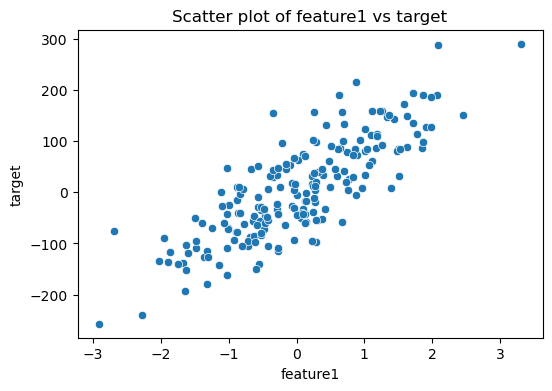

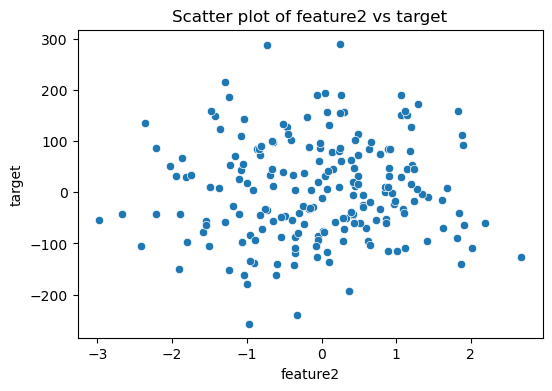

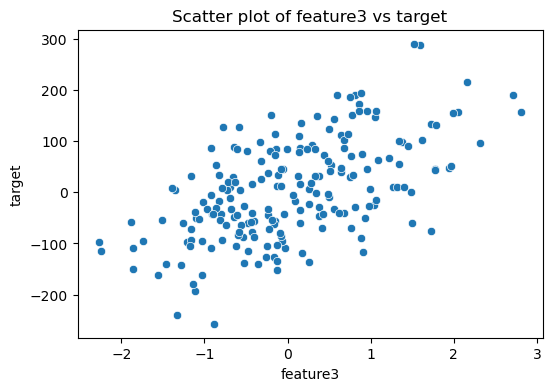

In [28]:
for column in X.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=X[column], y=y)
    plt.title(f'Scatter plot of {column} vs target')
    plt.xlabel(column)
    plt.ylabel('target')
    plt.show()

## Normality
    Response variable should be N.D with mean µ and variance σ2

    Residual N.D with mean µ = 0 and variance σ2

        1. displot
        2. kdeplot
        3. Andreson darling test
        4. Shapiro-Wilk Test

<Figure size 600x500 with 0 Axes>

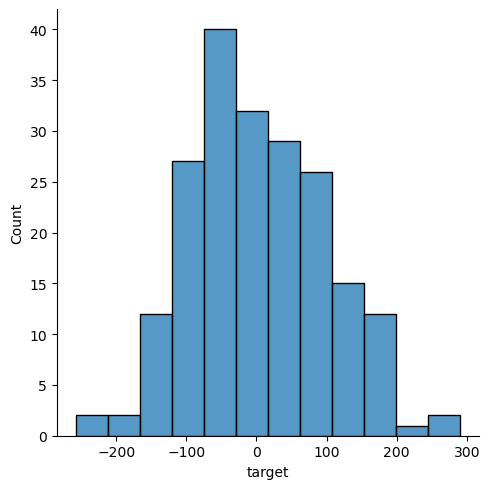

In [29]:
plt.figure(figsize = (6,5))
sns.displot(df['target'])
plt.show()

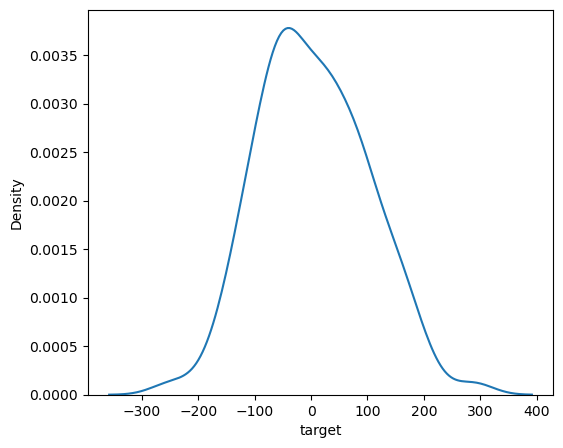

In [31]:
plt.figure(figsize = (6,5))
sns.kdeplot(df['target'])
plt.show()

    Anderson-Darling test statistic for normality
        Ho: The data follows a normal distribution.
        
        In this test, 
            if statistical value > critical value at a given significance level, you reject the null hypothesis (Ho).
            meaning : Data is not normally distributed!

In [32]:
from scipy.stats import anderson

anderson_stat, anderson_critical_values, anderson_significance_levels = anderson(df['target'])
print(f"Anderson-Darling Test\n")
print(f"Statistic: {anderson_stat}")
print(f"Anderson_Critical_Values : {anderson_critical_values}")
print("Anderson_Significance_Levels:", anderson_significance_levels)

# Perform the Anderson-Darling test
for crit_val, sig_level in zip(anderson_critical_values, anderson_significance_levels):
    if anderson_stat > crit_val:
        print(f"At {sig_level}% significance level : Data not normally distributed")
    else:
        print(f"At {sig_level}% significance level : Data normally distributed")

Anderson-Darling Test

Statistic: 0.5444064933784034
Anderson_Critical_Values : [0.565 0.644 0.772 0.901 1.071]
Anderson_Significance_Levels: [15.  10.   5.   2.5  1. ]
At 15.0% significance level : Data normally distributed
At 10.0% significance level : Data normally distributed
At 5.0% significance level : Data normally distributed
At 2.5% significance level : Data normally distributed
At 1.0% significance level : Data normally distributed


## Multicollinearity
    There should no correlation among independent variable. If we have multicollinearity then we get false significance.
    
 VIF value 

**Interpretation:**

* All features have **VIF ≈ 1**, which is **excellent**.
* There is **essentially no multicollinearity** between these features.
* You can safely include all three features in your regression model without worrying about inflated standard errors.

In [33]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Independent Variable
X = df.drop('target', axis = 1)

x1_vif = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

vif_df = pd.DataFrame({'Variable': (X.columns), 'VIF': x1_vif})
vif_df

,Variable,VIF
0,feature1,1.002545
1,feature2,1.003410
2,feature3,1.005937


| Feature   | VIF      | Interpretation                               |
|-----------|----------|---------------------------------------------|
| feature1  | 1.002545 | No multicollinearity; safe to include       |
| feature2  | 1.003410 | No multicollinearity; safe to include       |
| feature3  | 1.005937 | No multicollinearity; safe to include       |

In [34]:
import statsmodels.api as sm

vif_col = list(vif_df.Variable)

X1 = df[vif_col]
y1 = df['target']

model1 = sm.OLS(y1,X1).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 target   R-squared (uncentered):                   0.961
Model:                            OLS   Adj. R-squared (uncentered):              0.960
Method:                 Least Squares   F-statistic:                              1602.
Date:                Wed, 11 Mar 2026   Prob (F-statistic):                   4.72e-138
Time:                        11:42:37   Log-Likelihood:                         -875.50
No. Observations:                 200   AIC:                                      1757.
Df Residuals:                     197   BIC:                                      1767.
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
feature1      73.9983      1.323     55.930      0.000      71.389      76.607
feature2      -0.0525      1.302     -0.040      0.968      -2.621       2.516
feature3      53.8460      1.416     38.039      0.000      51.054      56.638
==============================================================================
Omnibus:                        1.799   Durbin-Watson:                   2.004
Prob(Omnibus):                  0.407   Jarque-Bera (JB):                1.454
Skew:                           0.116   Prob(JB):                        0.483
Kurtosis:                       3.348   Cond. No.                         1.12
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [35]:
X2 = df.drop(['feature2','target'], axis = 1)
#Dependent Variable
y2 = df['target']

model2 = sm.OLS(y2,X2).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 target   R-squared (uncentered):                   0.961
Model:                            OLS   Adj. R-squared (uncentered):              0.960
Method:                 Least Squares   F-statistic:                              2415.
Date:                Wed, 11 Mar 2026   Prob (F-statistic):                   8.50e-140
Time:                        11:43:55   Log-Likelihood:                         -875.50
No. Observations:                 200   AIC:                                      1755.
Df Residuals:                     198   BIC:                                      1762.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
feature1      73.9985      1.320     56.073      0.000      71.396      76.601
feature3      53.8426      1.410     38.198      0.000      51.063      56.622
==============================================================================
Omnibus:                        1.788   Durbin-Watson:                   2.004
Prob(Omnibus):                  0.409   Jarque-Bera (JB):                1.444
Skew:                           0.115   Prob(JB):                        0.486
Kurtosis:                       3.347   Cond. No.                         1.09
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

---

## **1. Model Overview**

| Metric                      | Model 1 (3 features)         | Model 2 (2 features, dropped feature2) |
| --------------------------- | ---------------------------- | -------------------------------------- |
| Features                    | feature1, feature2, feature3 | feature1, feature3                     |
| R-squared (uncentered)      | 0.961                        | 0.961                                  |
| Adj. R-squared (uncentered) | 0.960                        | 0.960                                  |
| F-statistic                 | 1602                         | 2415                                   |
| Prob(F-statistic)           | 4.72e-138                    | 8.50e-140                              |
| Coefficients significant    | feature1 & feature3 only     | feature1 & feature3                    |
| Durbin-Watson               | 2.004                        | 2.004                                  |
| Condition Number            | 1.12                         | 1.09                                   |

**Observation:**

* Both models explain **96.1% of the variance**, so predictive power is essentially identical.
* Adjusted R² is also identical, showing removing feature2 did not harm the model.
* F-statistic **increased** in the second model (2415 vs 1602), which indicates the remaining predictors now explain variance **more efficiently**, because the irrelevant feature2 was removed.
* Both models satisfy assumptions (no autocorrelation, normal residuals, no multicollinearity).

---

In [36]:
X = df.drop('target', axis = 1)
y = df['target']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size = 0.2, random_state = 0)

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression().fit(X_train, y_train)

ytest_predicted = linear_model.predict(X_test)

In [38]:
from sklearn.metrics import r2_score

test_accuracy = r2_score(y_test, ytest_predicted)
print(f"test_accuracy = {test_accuracy * 100}")

test_accuracy = 94.41316426714629


In [39]:
ytrain_predicted = linear_model.predict(X_train)
train_accuracy = r2_score(y_train, ytrain_predicted)

print(f"train_accuracy = {train_accuracy * 100}")

train_accuracy = 96.20692189112015
